## **1. Setup & Load Data**

Kita akan memuat data yang sudah bersih (ReviewAppDiscord_Clean.csv) dan data asli (ReviewAppDiscord.csv) jika ingin membandingkan panjang karakter sebelum dan sesudah diproses.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Load data hasil preprocessing
df = pd.read_csv('ReviewAppDiscord_Clean.csv')

## **2. Visualisasi Distribusi Rating**

Langkah ini untuk melihat apakah ulasan Discord didominasi oleh bintang 5 (senang) atau bintang 1 (kecewa).

/tmp/ipykernel_4487/3134780576.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='score', data=df, palette='viridis')


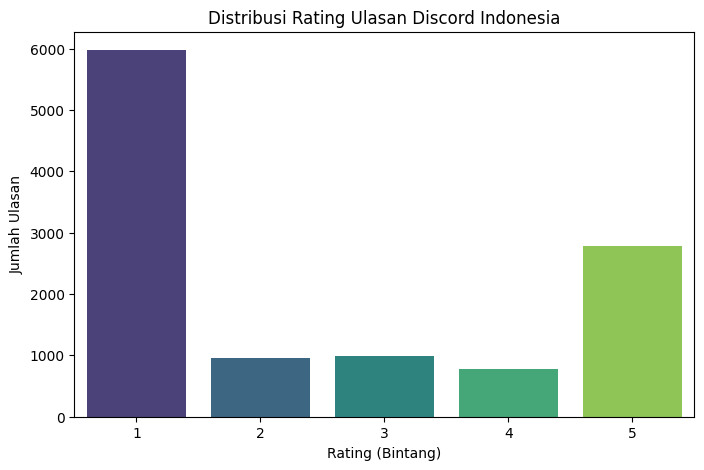

In [2]:
plt.figure(figsize=(8, 5))
sns.countplot(x='score', data=df, palette='viridis')
plt.title('Distribusi Rating Ulasan Discord Indonesia')
plt.xlabel('Rating (Bintang)')
plt.ylabel('Jumlah Ulasan')
plt.show()

## **3. Analisis Panjang Ulasan**

Biasanya ulasan negatif cenderung lebih panjang karena berisi keluhan detail.

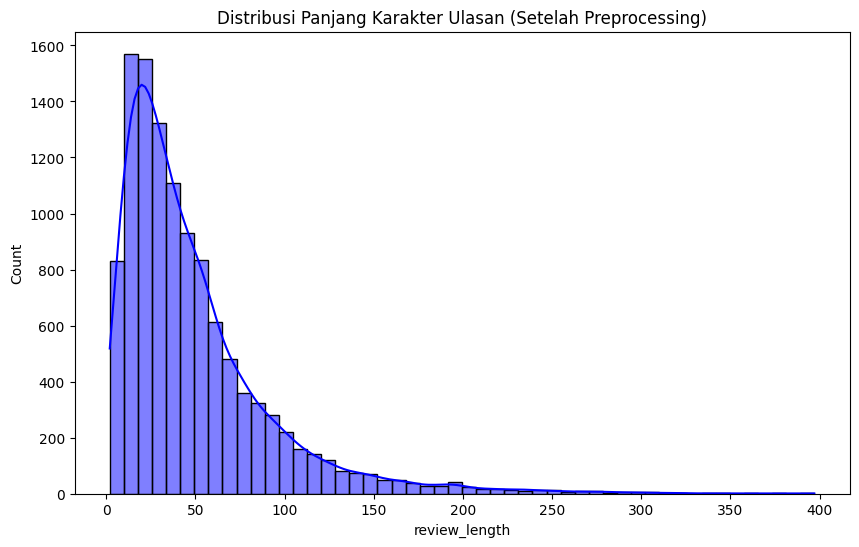

In [3]:
df['review_length'] = df['content_stemmed'].str.len()

plt.figure(figsize=(10, 6))
sns.histplot(df['review_length'], bins=50, kde=True, color='blue')
plt.title('Distribusi Panjang Karakter Ulasan (Setelah Preprocessing)')
plt.show()

## **4. WordCloud: Visualisasi Kata Kunci Terpopuler**

Membuat "awan kata" untuk melihat kata apa yang paling ikonik dari seluruh dataset.

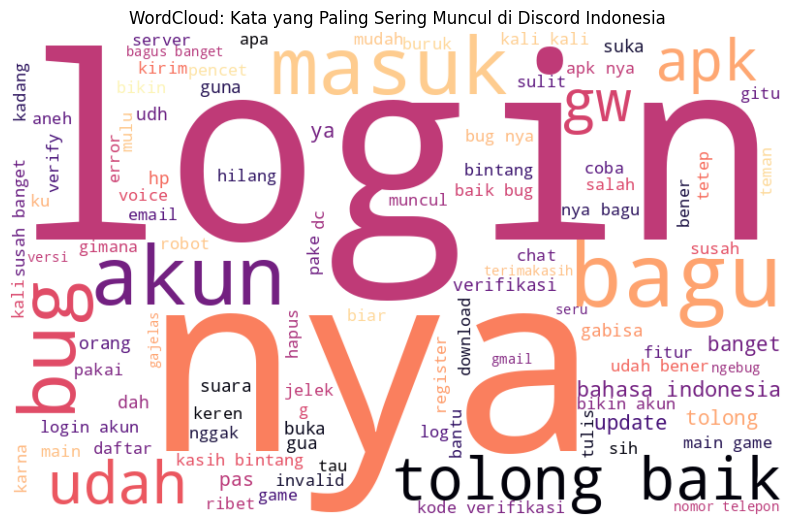

In [4]:
all_words = ' '.join([text for text in df['content_stemmed'].astype(str)])
wordcloud = WordCloud(width=800, height=500, background_color='white',
                      colormap='magma', max_words=100).generate(all_words)

plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud: Kata yang Paling Sering Muncul di Discord Indonesia')
plt.show()

## **5. Top N-Gram Analysis (Bigrams)**

kita tidak hanya melihat 1 kata (unigram), tapi 2 kata berdampingan (bigrams) untuk melihat konteks. Contoh: "koneksi buruk", "lancar jaya".

/tmp/ipykernel_4487/1618001158.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=y, y=x, palette='rocket')


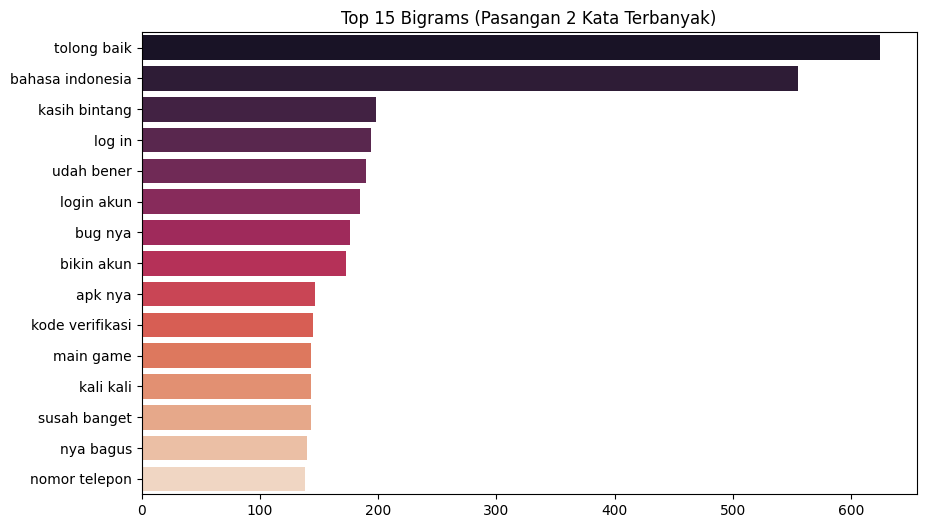

In [5]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_n_bigram(corpus, n=None):
    vec = CountVectorizer(ngram_range=(2, 2)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]

top_bigrams = get_top_n_bigram(df['content_stemmed'].astype(str), 15)
x, y = map(list, zip(*top_bigrams))

plt.figure(figsize=(10, 6))
sns.barplot(x=y, y=x, palette='rocket')
plt.title('Top 15 Bigrams (Pasangan 2 Kata Terbanyak)')
plt.show()